In [1]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


def rename_techs(label: str) -> str:
    """
    Rename technology labels for better readability.

    Removes some prefixes and renames if certain conditions defined in function body are met.

    Parameters
    ----------
    label: str
        Technology label to be renamed

    Returns
    -------
    str
        Renamed label
    """
    prefix_to_remove = [
        "residential ",
        "services ",
        "urban ",
        "rural ",
        "central ",
        "decentral ",
    ]

    rename_if_contains = [
        "CHP",
        "gas boiler",
        "biogas",
        "solar thermal",
        "air heat pump",
        "ground heat pump",
        "resistive heater",
        "Fischer-Tropsch",
    ]

    rename_if_contains_dict = {
        "water tanks": "hot water storage",
        "retrofitting": "building retrofitting",
        # "H2 Electrolysis": "hydrogen storage",
        # "H2 Fuel Cell": "hydrogen storage",
        # "H2 pipeline": "hydrogen storage",
        "battery": "battery storage",
        "H2 for industry": "H2 for industry",
        "land transport fuel cell": "land transport fuel cell",
        "land transport oil": "land transport oil",
        "oil shipping": "shipping oil",
        # "CC": "CC"
    }

    rename = {
        "solar": "solar PV",
        "Sabatier": "methanation",
        "offwind": "offshore wind",
        "offwind-ac": "offshore wind (AC)",
        "offwind-dc": "offshore wind (DC)",
        "offwind-float": "offshore wind (Float)",
        "onwind": "onshore wind",
        "ror": "hydroelectricity",
        "hydro": "hydroelectricity",
        "PHS": "hydroelectricity",
        "NH3": "ammonia",
        "co2 Store": "DAC",
        "co2 stored": "CO2 sequestration",
        "AC": "transmission lines",
        "DC": "transmission lines",
        "B2B": "transmission lines",
        "co2-ets": "Carbon Markets"
    }

    for ptr in prefix_to_remove:
        if label[: len(ptr)] == ptr:
            label = label[len(ptr) :]

    for rif in rename_if_contains:
        if rif in label:
            label = rif

    for old, new in rename_if_contains_dict.items():
        if old in label:
            label = new

    for old, new in rename.items():
        if old == label:
            label = new
    return label


preferred_order = pd.Index(
    [
        "transmission lines",
        "hydroelectricity",
        "hydro reservoir",
        "run of river",
        "pumped hydro storage",
        "solid biomass",
        "biogas",
        "onshore wind",
        "offshore wind",
        "offshore wind (AC)",
        "offshore wind (DC)",
        "solar PV",
        "solar thermal",
        "solar rooftop",
        "solar",
        "building retrofitting",
        "ground heat pump",
        "air heat pump",
        "heat pump",
        "resistive heater",
        "power-to-heat",
        "gas-to-power/heat",
        "CHP",
        "OCGT",
        "gas boiler",
        "gas",
        "natural gas",
        "methanation",
        "ammonia",
        "hydrogen storage",
        "power-to-gas",
        "power-to-liquid",
        "battery storage",
        "hot water storage",
        "CO2 sequestration",
    ]
)


In [2]:
import yaml

with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']
tech_colors['co2-ets'] = 'black'
tech_colors['Carbon Markets'] = 'black'
tech_colors['Battery Storage'] = 'green'
tech_colors['Combined-Cycle Gas'] = tech_colors['CCGT']
tech_colors['Open-Cycle Gas'] = tech_colors['OCGT']

Dropping technology with costs below 1 EUR billion per year
System cost difference to 2000 TWh Methane Consumption: 204 EUR billion per year


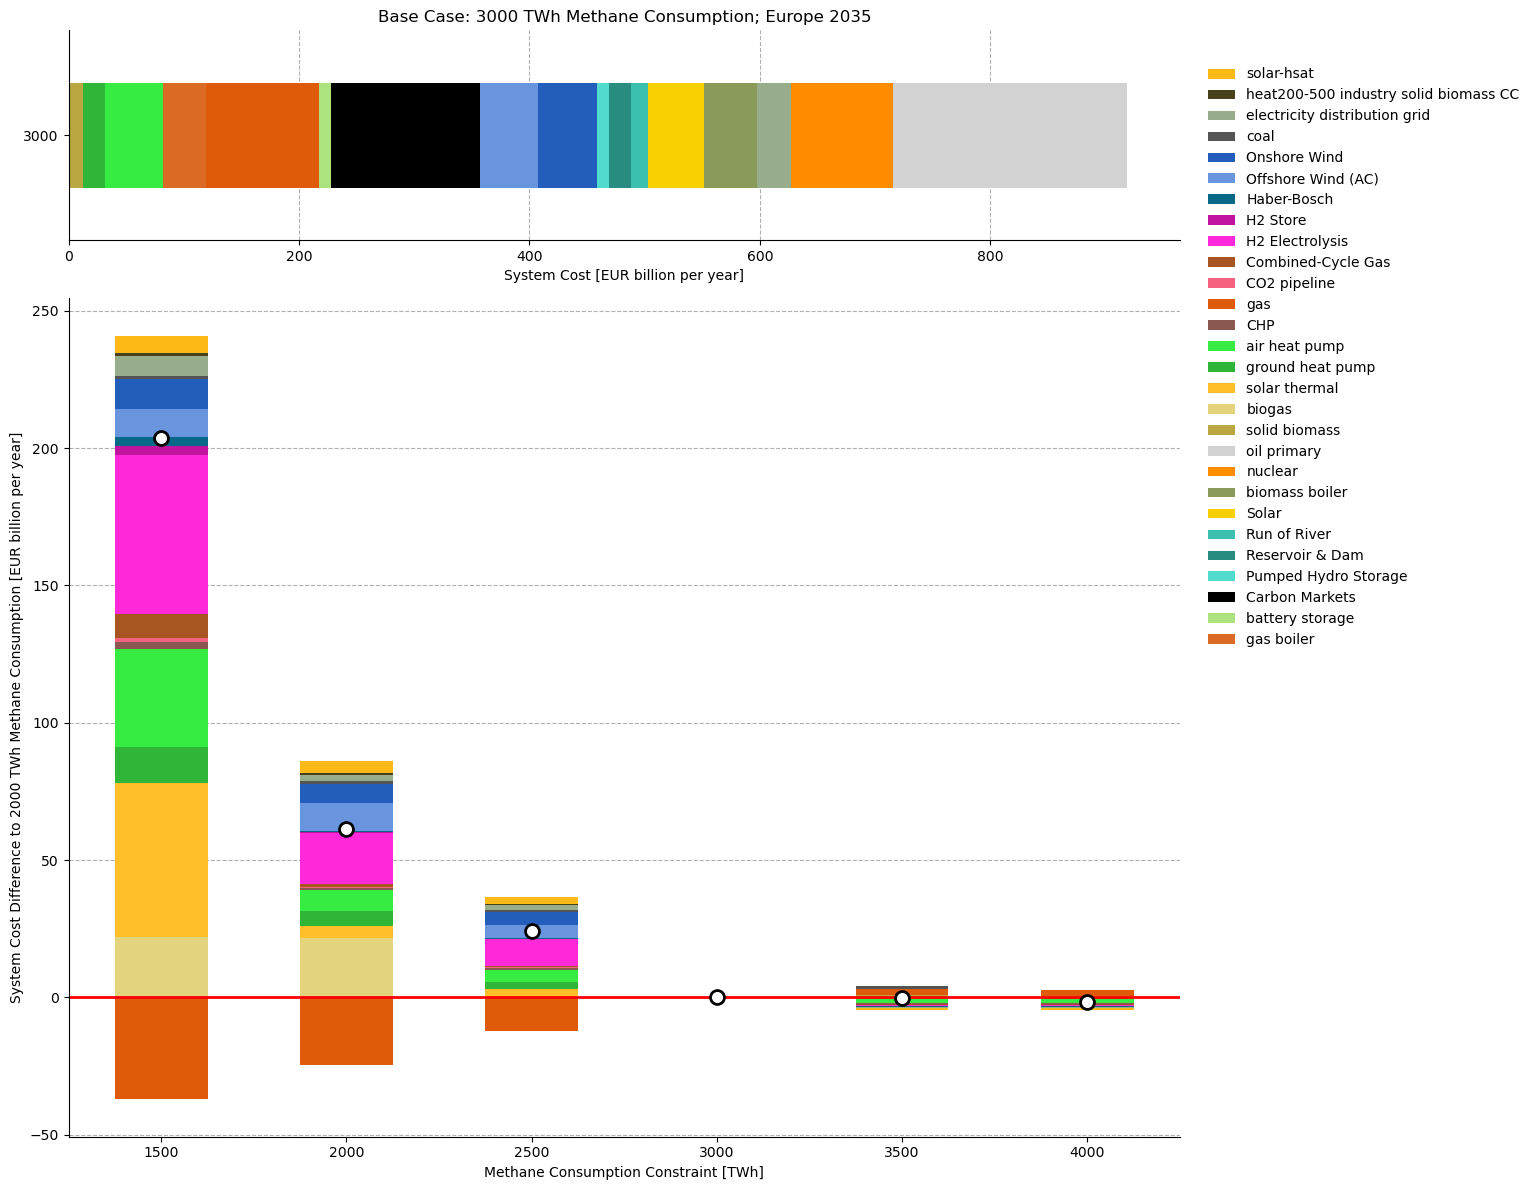

In [6]:
def plot_costs(ax, cost_df):

    df = cost_df.groupby("carrier").sum()

    # convert to billions
    df = df / 1e9

    df = df.groupby(df.index.map(rename_techs)).sum()

    cost_threshold = 1
    to_drop = df.index[df.max(axis=1) < cost_threshold]

    print(
        f"Dropping technology with costs below {cost_threshold} EUR billion per year"
    )

    df = df.drop(to_drop)

    print(f"System cost difference to 2000 TWh Methane Consumption: {round(df.sum().iloc[0])} EUR billion per year")

    new_index = preferred_order.intersection(df.index).append(
        df.index.difference(preferred_order)
    )

    df.loc[new_index].T.plot(
        kind="bar",
        ax=ax,
        stacked=True,
        color=[tech_colors[i] for i in new_index],
        legend=False
    )

    # Add sum markers for each column
    column_sums = df.sum()
    x_positions = range(len(column_sums))
    ax.scatter(x_positions, column_sums, color='white', edgecolors='black', 
               s=100, zorder=5, linewidths=2)

    handles, labels = ax.get_legend_handles_labels()

    handles.reverse()
    labels.reverse()

    return handles, labels, new_index


def plot_base_costs(ax, cost_df, base_col):

    df = cost_df[[base_col]].groupby("carrier").sum()
    
    # convert to billions
    df = df / 1e9
    
    df = df.groupby(df.index.map(rename_techs)).sum()
    
    cost_threshold = 10
    to_drop = df.index[df.max(axis=1) < cost_threshold]
    df = df.drop(to_drop)
    
    # Reindex to match new_index order
    new_index = preferred_order.intersection(df.index).append(
        df.index.difference(preferred_order)
    )

    df = df.reindex(new_index).dropna()
    
    df.T.plot(
        kind="barh",
        ax=ax,
        stacked=True,
        color=[tech_colors[i] for i in df.index],
        legend=False
    )
    
    handles, labels = ax.get_legend_handles_labels()

    handles.reverse()
    labels.reverse()

    return handles, labels, new_index


n_header = 5

cost_df = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'costs.csv',
    index_col=list(range(3)),
    header=list(range(n_header))
)
cost_df.columns = cost_df.columns.get_level_values(-1)

base_col = '3000'
base = cost_df[base_col].copy()

diff = cost_df.sub(base, axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [0.5, 2]})

# plot_costs(ax, cost_df)
# handles, labels, new_index = plot_costs(ax2, diff)
handles1, labels1, _ = plot_costs(ax2, diff)

handles, labels, new_index = plot_base_costs(ax1, cost_df, base_col)

# Merge handles and labels from both plots
all_handles = handles1 + handles
all_labels = labels1 + labels

# Remove duplicates while preserving order
seen = set()
merged_handles = []
merged_labels = []
for h, l in zip(all_handles, all_labels):
    if l not in seen:
        seen.add(l)
        merged_handles.append(h)
        merged_labels.append(l)

handles = merged_handles
labels = merged_labels

ax1.set_xlabel("System Cost [EUR billion per year]")
ax1.set_ylabel("")
ax1.set_title(f"Base Case: {base_col} TWh Methane Consumption; Europe 2035")
ax1.grid(axis="x", linestyle='--')
ax1.set_axisbelow(True)

ax2.set_ylabel("System Cost Difference to 2000 TWh Methane Consumption [EUR billion per year]")

ax2.set_xlabel("")

ax2.grid(axis="y", linestyle='--')
ax2.set_axisbelow(True)

ax2.axhline(0, color='red', linewidth=2)

# Create shared legend
fig.legend(
    handles, labels, ncol=1, loc="upper left", bbox_to_anchor=[1, 0.95], frameon=False
)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Remove rotation from x-axis tick labels
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=0)

ax2.set_xlabel("Methane Consumption Constraint [TWh]")

# fig.savefig(snakemake.output.costs, bbox_inches="tight")
plt.tight_layout()
plt.show(fig)

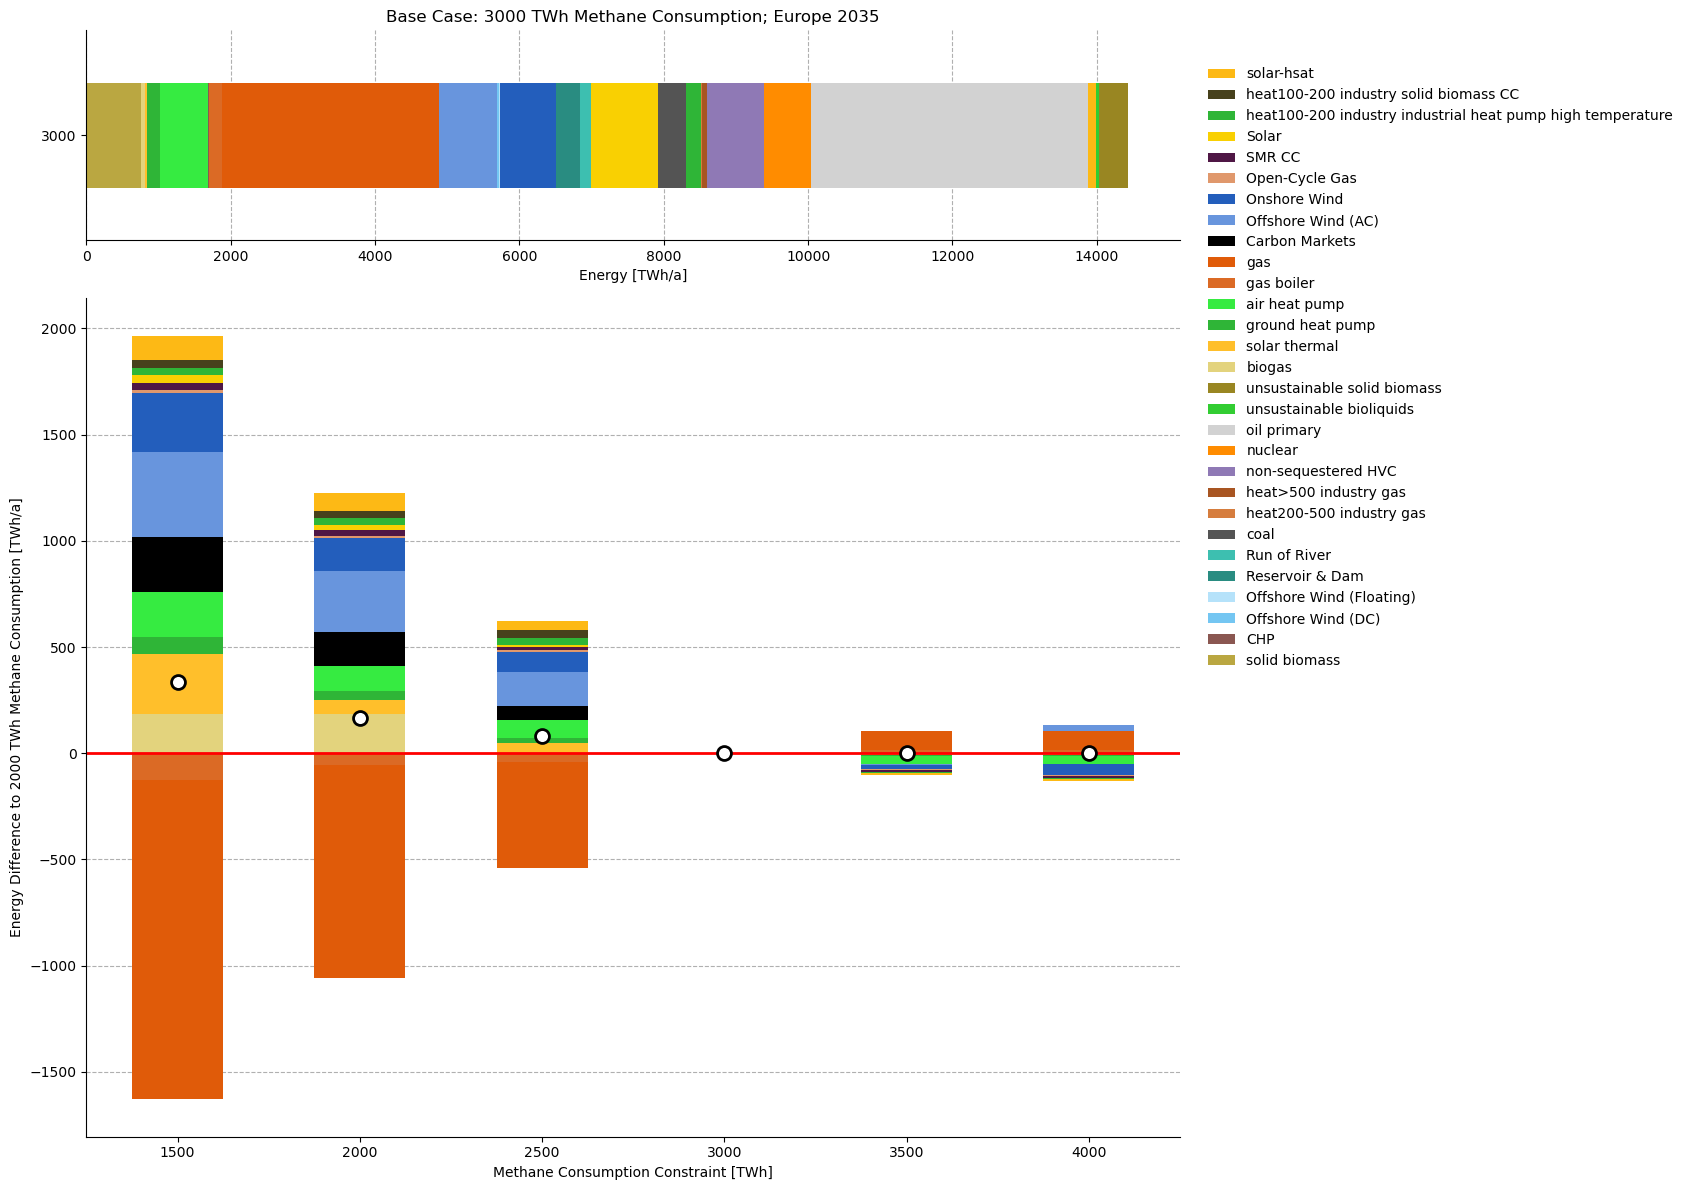

In [5]:
def plot_energy(ax, energy_df):

    df = energy_df.groupby("carrier").sum()

    df = df / 1e6

    df = df.groupby(df.index.map(rename_techs)).sum()

    energy_threshold = 10
    to_drop = df.index[df.max(axis=1) < energy_threshold]
    df = df.drop(to_drop)

    new_index = preferred_order.intersection(df.index).append(
        df.index.difference(preferred_order)
    )

    df.loc[new_index].T.plot(
        kind="bar",
        ax=ax,
        stacked=True,
        color=[tech_colors[i] for i in new_index],
        legend=False
    )

    # Add scatter points for column sums
    column_sums = df.loc[new_index].sum(axis=0)
    x_positions = range(len(column_sums))
    ax.scatter(x_positions, column_sums, color='white', edgecolors='black', s=100, zorder=5, linewidths=2)

    handles, labels = ax.get_legend_handles_labels()

    handles.reverse()
    labels.reverse()

    return handles, labels, new_index


def plot_base_energy(ax, energy_df, base_col):

    df = energy_df[[base_col]].groupby("carrier").sum()
    
    df = df / 1e6
    
    df = df.groupby(df.index.map(rename_techs)).sum()
    
    energy_threshold = 5
    to_drop = df.index[df.max(axis=1) < energy_threshold]
    df = df.drop(to_drop)
    
    # Reindex to match new_index order
    new_index = preferred_order.intersection(df.index).append(
        df.index.difference(preferred_order)
    )

    df = df.reindex(new_index).dropna()
    
    df.T.plot(
        kind="barh",
        ax=ax,
        stacked=True,
        color=[tech_colors[i] for i in df.index],
        legend=False
    )
    
    handles, labels = ax.get_legend_handles_labels()

    handles.reverse()
    labels.reverse()

    return handles, labels, new_index


n_header = 5

energy_df = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'energy.csv',
    index_col=list(range(2)),
    header=list(range(n_header))
)
energy_df.columns = energy_df.columns.get_level_values(-1)

base_col = '3000'
base = energy_df[base_col].copy()

diff = energy_df.sub(base, axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [0.5, 2]})

# plot_costs(ax, cost_df)
# handles, labels, new_index = plot_costs(ax2, diff)
handles1, labels1, _ = plot_energy(ax2, diff)

handles, labels, new_index = plot_base_energy(ax1, energy_df, base_col)

# Merge handles and labels from both plots
all_handles = handles1 + handles
all_labels = labels1 + labels

# Remove duplicates while preserving order
seen = set()
merged_handles = []
merged_labels = []
for h, l in zip(all_handles, all_labels):
    if l not in seen:
        seen.add(l)
        merged_handles.append(h)
        merged_labels.append(l)

handles = merged_handles
labels = merged_labels

ax1.set_xlabel("Energy [TWh/a]")
ax1.set_ylabel("")
ax1.set_title(f"Base Case: {base_col} TWh Methane Consumption; Europe 2035")
ax1.grid(axis="x", linestyle='--')
ax1.set_axisbelow(True)

ax2.set_ylabel("Energy Difference to 2000 TWh Methane Consumption [TWh/a]")

ax2.set_xlabel("")

ax2.grid(axis="y", linestyle='--')
ax2.set_axisbelow(True)

ax2.axhline(0, color='red', linewidth=2)

# Create shared legend
fig.legend(
    handles, labels, ncol=1, loc="upper left", bbox_to_anchor=[1, 0.95], frameon=False
)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Remove rotation from x-axis tick labels
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=0)

ax2.set_xlabel("Methane Consumption Constraint [TWh]")

# fig.savefig(snakemake.output.costs, bbox_inches="tight")
plt.tight_layout()
plt.show(fig)

In [40]:
cost_df.sum() / 1e9

wiggle
1500    953.334190
2000    942.317985
3000    936.444028
dtype: float64